# Credit Risk Scoring — Explainable Machine Learning for Imbalanced Classification

**Dataset:** `Dev_data_to_be_shared.csv` — 96,806 accounts with 1,216 original columns.

This project develops an end-to-end **credit risk classification pipeline** for predicting the binary target `bad_flag`, where:

- `0` = Good account
- `1` = Bad account

The dataset is unusually wide and highly imbalanced, so the notebook focuses on four areas that matter in practical credit-risk modelling:

1. **Memory-efficient data handling** for a 1,216-column dataset.
2. **Leakage-aware preprocessing** and imbalance handling.
3. **Model comparison** using metrics appropriate for a rare positive class.
4. **Explainability and risk segmentation** to connect model output with business decision-making.

## Business question

> **Can customer account attributes be used to identify higher-risk accounts, and which modelling approach provides the strongest balance between ranking risky accounts and correctly identifying actual bad accounts?**

## Models compared

- **Logistic Regression** — interpretable linear baseline
- **Random Forest** — non-linear ensemble baseline
- **XGBoost** — gradient-boosted tree model
- **K-Means** — optional unsupervised behavioural segmentation

SHAP is also used to investigate which anonymised features contribute most strongly to XGBoost predictions.

## Important dataset limitation

The predictive columns are anonymised (`onus_attribute_2`, `bureau_147`, etc.). Their business meanings are not supplied.

This means the notebook can explain **which variables influence the model**, but it cannot responsibly claim what those variables represent in real-world lending terms.

That limitation is treated as a core finding rather than filled with speculative feature descriptions.

## 0. Setup & Imports

This section loads the Python libraries required for data preparation, machine learning, evaluation, clustering and explainability.

The dataset contains almost 97,000 accounts and more than 1,200 columns, so memory management is considered from the beginning.

The notebook uses:

- **Pandas / NumPy** for data handling
- **Matplotlib / Seaborn** for visualisation
- **Scikit-learn** for preprocessing, classification, evaluation and clustering
- **XGBoost** for gradient boosting
- **SHAP** for model explainability

A fixed random seed is used where supported to make the modelling process reproducible.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans

# Evaluation — the exact metric set requested
from sklearn.metrics import (
    confusion_matrix, precision_recall_curve, auc, roc_curve,
    recall_score, classification_report, f1_score,
    precision_recall_fscore_support, ConfusionMatrixDisplay
)

# Explainability
import shap

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import gc


### Setup conclusion

The environment is configured for a high-dimensional binary classification problem.

The key design decision is to avoid treating this like a small, conventional tabular dataset: the notebook uses memory-conscious loading and avoids unnecessary copies of the full feature matrix.

## 1. Upload Dataset

The dataset contains **1,216 original columns**, including the target and account identifier.

Loading the complete file with Pandas' default `float64` representation would consume substantially more memory than necessary. The notebook therefore performs a lightweight first pass to identify columns with excessive missingness before loading the retained feature set.

### Missingness rule

Features with **more than 50% missing values** are excluded.

This is a modelling assumption rather than a universal rule. The purpose is to remove columns that contain too little observed information to be useful without introducing excessive imputation.

The scan is performed in chunks so that the complete dataset does not need to remain in memory solely for the missingness calculation.

In [ ]:
FILE_PATH = "/content/Dev_data_to_be_shared.csv"  # update path if running locally instead of Colab

# --- Step 1: chunked null-percentage pass (memory-safe — never loads the full file at once) ---
all_cols = pd.read_csv(FILE_PATH, nrows=0).columns.tolist()
null_counts = pd.Series(0, index=all_cols, dtype='int64')
total_rows = 0

for chunk in pd.read_csv(FILE_PATH, chunksize=10_000):
    null_counts += chunk.isnull().sum()
    total_rows += len(chunk)

null_pct = (null_counts / total_rows * 100).sort_values(ascending=False)
print(f"Scanned {total_rows:,} rows.")
print(f"Columns with >50% missing: {(null_pct > 50).sum()} (these will be dropped)")
null_pct.head(10)


Scanned 96,806 rows.
Columns with >50% missing: 19 (these will be dropped)


,0
bureau_447,100.000000
bureau_436,100.000000
bureau_449,94.124331
bureau_148,93.552053
bureau_448,90.028511
onus_attribute_44,88.006942
onus_attribute_43,88.006942
onus_attribute_48,88.006942
onus_attribute_47,88.006942
onus_attribute_45,88.006942


In [ ]:
# --- Step 2: drop the near-empty columns, then load the rest as float32 ---
MISSING_THRESHOLD = 50  # % missing above which a column is dropped — see Section 3 for why

drop_cols = null_pct[null_pct > MISSING_THRESHOLD].index.tolist()
keep_cols = [c for c in all_cols if c not in drop_cols]

dtype_map = {c: 'float32' for c in keep_cols if c not in ('account_number', 'bad_flag')}
dtype_map['bad_flag'] = 'int8'

df_raw = pd.read_csv(FILE_PATH, usecols=keep_cols, dtype=dtype_map)

print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns "
      f"(dropped {len(drop_cols)} columns with >{MISSING_THRESHOLD}% missing)")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e9:.2f} GB")


Loaded: 96,806 rows x 1197 columns (dropped 19 columns with >50% missing)
Memory usage: 0.46 GB


### Loading result

The scan processes **96,806 accounts** and identifies **19 columns** with more than 50% missing values.

After removing those columns, the working dataset contains:

- **96,806 rows**
- **1,197 columns**
- approximately **0.46 GB** of memory usage

The reduction is modest in row count but important for making the subsequent modelling steps more practical in a constrained environment such as Google Colab.

## 2. Display Dataset

This section performs a high-level inspection of the retained dataset.

Because the feature space is extremely wide, the objective is not to print every column individually. Instead, the notebook establishes the row/column dimensions and displays representative observations.

The target and account identifier are kept separate conceptually from the predictive attributes.

In [ ]:
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns\n")
df_raw.head(5)


Shape: 96,806 rows x 1197 columns



,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_41,bureau_enquiry_42,bureau_enquiry_43,bureau_enquiry_44,bureau_enquiry_45,bureau_enquiry_46,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50
0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,2.0,4.0,0.0,1.0,0.0,0.0,0.0,2.0,3.0
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.0,0.0,11.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,38.0,0.0,38.0,0.0,6.0,0.0,0.0,0.0,0.0,30.0
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Dataset inspection conclusion

The retained data remains extremely high-dimensional, with thousands of potential relationships between attributes and the binary outcome.

This makes feature-family analysis, missingness analysis and careful preprocessing more useful than attempting to manually interpret every individual column.

## 3. Clean Dataset

Cleaning focuses on structural integrity rather than aggressively transforming the feature values.

The notebook checks:

- Which columns were removed for excessive missingness
- Whether account identifiers are duplicated
- Whether complete rows are duplicated
- How much missing data remains after the initial feature removal

Remaining missing values are **not imputed here**.

Instead, imputation is deliberately postponed until after the train/test split so that the median values used for imputation are learned from the training set only. This prevents test-set information from influencing the preprocessing step.

In [ ]:
# Column families, by prefix — this is the closest thing to a schema this dataset gives us
import re
families = {}
for c in df_raw.columns:
    if c in ('account_number', 'bad_flag'):
        continue
    fam = 'bureau_enquiry' if c.startswith('bureau_enquiry') else \
          'bureau' if c.startswith('bureau') else \
          'onus_attribute' if c.startswith('onus_attribute') else \
          'transaction_attribute' if c.startswith('transaction_attribute') else 'other'
    families[fam] = families.get(fam, 0) + 1

pd.Series(families).sort_values(ascending=False)


,0
transaction_attribute,664
bureau,439
bureau_enquiry,50
onus_attribute,42


### Feature-family structure

The retained attributes fall into four identifiable families based on their prefixes:

- `transaction_attribute`
- `bureau`
- `bureau_enquiry`
- `onus_attribute`

The family sizes are highly uneven. The transaction and bureau blocks contain hundreds of variables, while the on-us block contains far fewer.

This family structure becomes useful later for group-level feature engineering and interpretation.

In [ ]:
print(f"Columns dropped for >{MISSING_THRESHOLD}% missing ({len(drop_cols)}):")
print(drop_cols)
print()
print("Duplicate account_numbers:", df_raw['account_number'].duplicated().sum())
print("Duplicate full rows:", df_raw.duplicated().sum())
print()
remaining_missing = df_raw.isnull().sum().sum()
print(f"Missing values remaining across kept columns: {remaining_missing:,} "
      f"({remaining_missing / (df_raw.shape[0]*df_raw.shape[1]) * 100:.2f}% of all cells)")


Columns dropped for >50% missing (19):
['bureau_447', 'bureau_436', 'bureau_449', 'bureau_148', 'bureau_448', 'onus_attribute_44', 'onus_attribute_43', 'onus_attribute_48', 'onus_attribute_47', 'onus_attribute_45', 'onus_attribute_46', 'bureau_444', 'bureau_438', 'bureau_446', 'bureau_435', 'bureau_433', 'bureau_437', 'bureau_451', 'bureau_445']

Duplicate account_numbers: 0
Duplicate full rows: 0

Missing values remaining across kept columns: 17,837,454 (15.39% of all cells)


### Cleaning conclusion

The dataset contains **no duplicate account numbers and no duplicate full rows**.

However, substantial missingness remains among the retained variables. This is expected given the 50% removal threshold and reinforces the need for a principled imputation strategy during model preparation.

The data is therefore structurally usable, but its missingness pattern is itself an important characteristic of the problem.

## 4. Basic Analysis

The target distribution is the most important diagnostic in this project.

`bad_flag` is extremely imbalanced:

- The majority of accounts are labelled **Good (0)**.
- Only a small fraction are labelled **Bad (1)**.

This affects almost every modelling decision that follows.

For example, a classifier could achieve very high accuracy simply by predicting "Good" for nearly every account while failing to identify meaningful numbers of bad accounts.

For this reason, the notebook prioritises:

- Precision
- Recall
- F1
- PR-AUC

and uses ROC-AUC as a complementary ranking metric rather than relying on accuracy alone.

Class balance:
  Good (0): 95,434 (98.58%)
  Bad  (1): 1,372 (1.42%)


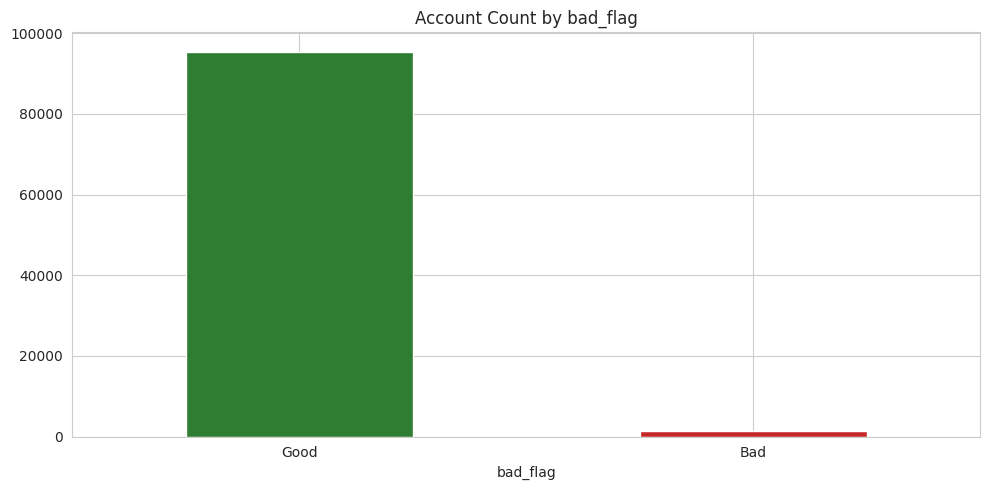

In [ ]:
# Class balance — this number drives every modeling decision from here on
bad_counts = df_raw['bad_flag'].value_counts()
bad_pct = df_raw['bad_flag'].value_counts(normalize=True) * 100

print("Class balance:")
print(f"  Good (0): {bad_counts[0]:,} ({bad_pct[0]:.2f}%)")
print(f"  Bad  (1): {bad_counts[1]:,} ({bad_pct[1]:.2f}%)")

fig, ax = plt.subplots()
bad_counts.plot(kind='bar', color=['#2e7d32', '#c62828'], ax=ax)
ax.set_xticklabels(['Good', 'Bad'], rotation=0)
ax.set_title('Account Count by bad_flag')
plt.tight_layout()
plt.show()


### Class-balance result

The dataset contains:

- **95,434 Good accounts (98.58%)**
- **1,372 Bad accounts (1.42%)**

The positive class therefore represents only **1.42%** of the dataset.

A useful baseline is the positive-class prevalence itself: a random ranking system would have a PR-AUC around **0.0142** under this class distribution.

This is why a PR-AUC of 0.08 can represent meaningful ranking improvement even though the corresponding precision at a fixed classification threshold may still be low.

### Figure 1 — Distribution of Good vs Bad Accounts

This bar chart visualises the severe class imbalance.

The purpose is diagnostic rather than predictive: it shows why accuracy alone would be misleading and why the modelling strategy needs explicit imbalance handling.

### Figure 2 — Missingness Distribution Across Retained Features

This histogram shows the percentage of missing values across the 1,195 retained predictive columns.

The graph answers two questions:

1. How much missingness remains after the >50% filtering rule?
2. Is missingness concentrated in a small number of columns or distributed broadly across the feature space?

The median retained-feature missingness is approximately **26.06%**, while only **29 of 1,195** retained features have no missing values.

This is substantial enough that missing-value handling is a core part of the modelling pipeline, not a minor cleanup step.

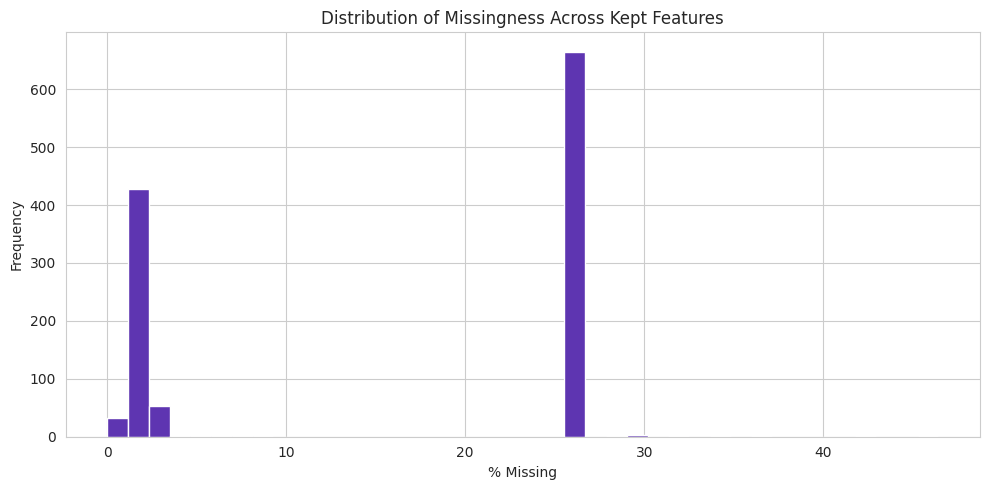

Median missingness among kept columns: 26.06%
Columns with 0% missing: 29 of 1195


In [ ]:
# Missingness distribution across the 1,195 kept feature columns
feature_cols = [c for c in df_raw.columns if c not in ('account_number', 'bad_flag')]
missing_pct_kept = (df_raw[feature_cols].isnull().mean() * 100)

fig, ax = plt.subplots()
missing_pct_kept.plot(kind='hist', bins=40, ax=ax, color='#5e35b1')
ax.set_title('Distribution of Missingness Across Kept Features')
ax.set_xlabel('% Missing')
plt.tight_layout()
plt.show()

print(f"Median missingness among kept columns: {missing_pct_kept.median():.2f}%")
print(f"Columns with 0% missing: {(missing_pct_kept == 0).sum()} of {len(feature_cols)}")


### Figure 3 — Top Features by Absolute Correlation with `bad_flag`

This ranking shows the strongest individual linear associations between the retained raw features and the target.

Correlation is used here as an **exploratory diagnostic**, not as the feature-selection rule for the final model.

A high absolute correlation does not establish causality, and a low individual correlation does not mean that a feature is useless: tree-based models can exploit non-linear relationships and interactions that correlation does not capture.

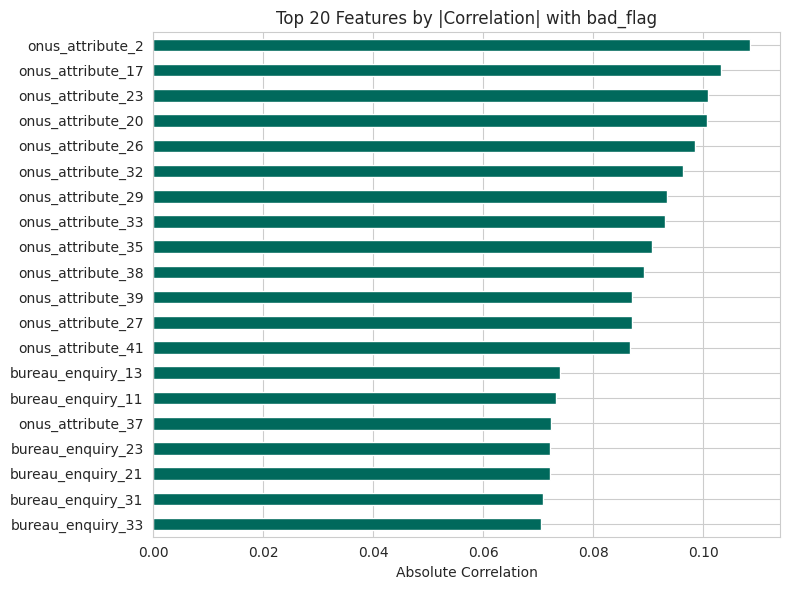

In [ ]:
# Top individual features by absolute correlation with the target — the closest thing to
# a "which raw columns matter" answer available before any modeling happens
corr_with_target = df_raw[feature_cols].corrwith(df_raw['bad_flag']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.head(20).sort_values().plot(kind='barh', ax=ax, color='#00695c')
ax.set_title('Top 20 Features by |Correlation| with bad_flag')
ax.set_xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()


### Correlation analysis conclusion

The strongest individual correlations are concentrated in the `onus_attribute` family, with `onus_attribute_2` leading at approximately **|r| = 0.108**.

This is notable because `onus_attribute` is the smallest major feature family. It suggests that some of the bank's own account-level behavioural variables contain disproportionate individual signal.

However, correlation alone cannot determine the final predictive contribution of a feature. The model-based SHAP analysis later provides a complementary view.

## 5. Prepare the Data

### 5.1 Feature Engineering — Group-Level Aggregates

Because the original variables are anonymised, conventional domain features such as income-to-debt ratios cannot be constructed responsibly.

Instead, the notebook creates summary statistics within each coherent feature family:

- Mean
- Standard deviation
- Sum
- Missing-value count

These are calculated separately for:

- `onus_attribute`
- `transaction_attribute`
- `bureau_enquiry`
- `bureau`

### Why this is useful

The raw feature space contains roughly 1,200 anonymised variables. Group-level aggregates provide a compact description of the overall magnitude, variability and completeness of each information block.

The raw variables are **not replaced**. The engineered features are added alongside them so that models can use both detailed individual signals and broader group-level summaries.

In [ ]:
feature_groups = {
    'onus_attribute': [c for c in feature_cols if c.startswith('onus_attribute')],
    'transaction_attribute': [c for c in feature_cols if c.startswith('transaction_attribute')],
    'bureau_enquiry': [c for c in feature_cols if c.startswith('bureau_enquiry')],
    'bureau': [c for c in feature_cols if c.startswith('bureau') and not c.startswith('bureau_enquiry')],
}

# Note: engineered directly onto df_raw (renamed df_feat below) rather than df_raw.copy() —
# a full copy of a 96,806 x 1,195 float32 frame would briefly double memory for no benefit,
# since the original df_raw isn't needed again after this point.
df_feat = df_raw
del df_raw

for group_name, cols in feature_groups.items():
    block = df_feat[cols].astype('float32')
    df_feat[f'{group_name}_mean'] = block.mean(axis=1).astype('float32')
    df_feat[f'{group_name}_std'] = block.std(axis=1).astype('float32')
    df_feat[f'{group_name}_sum'] = block.sum(axis=1).astype('float32')
    df_feat[f'{group_name}_missing_count'] = block.isnull().sum(axis=1).astype('float32')
    del block

engineered_cols = [c for c in df_feat.columns if any(
    c.endswith(suffix) for suffix in ('_mean', '_std', '_sum', '_missing_count')
)]
print(f"Added {len(engineered_cols)} group-level aggregate features:")
print(engineered_cols)


Added 16 group-level aggregate features:
['onus_attribute_mean', 'onus_attribute_std', 'onus_attribute_sum', 'onus_attribute_missing_count', 'transaction_attribute_mean', 'transaction_attribute_std', 'transaction_attribute_sum', 'transaction_attribute_missing_count', 'bureau_enquiry_mean', 'bureau_enquiry_std', 'bureau_enquiry_sum', 'bureau_enquiry_missing_count', 'bureau_mean', 'bureau_std', 'bureau_sum', 'bureau_missing_count']


### Feature-engineering result

The feature engineering step adds **16 group-level features**: four summary statistics for each of the four feature families.

This increases the modelling feature count from 1,195 retained raw predictors to **1,211 predictors**.

The engineered features are intended primarily as complementary summaries and interpretability aids rather than as replacements for the original attributes.

### 5.2 Train/Test Split, Imputation & Scaling

The train/test split is performed **before** imputation and scaling.

This ordering is critical:

> **Training data determines preprocessing parameters; test data is only transformed using those parameters.**

An 80/20 split is used with `stratify=y`.

Stratification is particularly important because only 1.42% of observations belong to the positive class. It helps maintain a comparable bad-account rate in the training and test sets.

### Imputation

Missing values are replaced using the **training-set median**.

### Scaling

Standardisation is applied for Logistic Regression. The tree-based models do not require scaled features, although the scaled version is retained for the linear model.

All preprocessing statistics are fitted using training data only.

In [ ]:
X = df_feat[feature_cols + engineered_cols].astype('float32')
y = df_feat['bad_flag']

# Save what later sections need in lightweight form before dropping the big objects
all_feature_names = list(X.columns)                                              # for SHAP labels
cluster_source = df_feat[['account_number', 'bad_flag'] + engineered_cols].copy()  # for Section 6.5

# df_feat's job is done once the above is extracted — dropping it frees ~0.5 GB
del df_feat
gc.collect()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Save indices so the optional clustering section can use the same train/test partition.
train_indices = X_train.index.copy()
test_indices = X_test.index.copy()

del X
gc.collect()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train bad rate: {y_train.mean():.4f} | Test bad rate: {y_test.mean():.4f}")


Train: (77444, 1211), Test: (19362, 1211)
Train bad rate: 0.0142 | Test bad rate: 0.0142


In [ ]:
# Median imputation, fit on train only.
# IMPORTANT: SimpleImputer and StandardScaler both default to float64 output regardless of
# input dtype — at ~1,210 features this silently doubles memory versus the float32 the data
# was loaded as. Explicit .astype('float32') after each step avoids that.
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train).astype('float32')
X_test_imp = imputer.transform(X_test).astype('float32')

# Standard scaling, fit on train only — needed for Logistic Regression, harmless for tree models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp).astype('float32')
X_test_scaled = scaler.transform(X_test_imp).astype('float32')

# Free X_train now that we have the numpy array we train on — X_test is kept (much smaller,
# 20% of the data) since Section 6.3 needs its index and columns for the risk-score table.
del X_train
gc.collect()

print("Preprocessing complete. Final feature count:", X_train_scaled.shape[1])


Preprocessing complete. Final feature count: 1211


### Preparation result

The split produces:

- **77,444 training accounts**
- **19,362 test accounts**
- **1,211 final predictors**

Both partitions retain a bad-account rate of approximately **1.42%**, confirming that stratification preserved the class distribution.

The final modelling matrices are available in both imputed and, where required, standardised form.

## 6. Machine Learning Modelling

### 6.1 Why Supervised Classification Fits the Problem

`bad_flag` is an observed binary outcome, so this is a **supervised binary classification problem**.

The objective is not simply to predict a class label. In credit-risk applications, the model's ability to **rank accounts by risk** can be more useful than a single yes/no classification threshold.

### 6.2 Handling Severe Class Imbalance

The positive class represents only **1.42%** of accounts.

The notebook therefore uses:

- `class_weight='balanced'` for Logistic Regression
- `class_weight='balanced'` for Random Forest
- `scale_pos_weight` for XGBoost

This changes the learning objective so that mistakes on the minority class receive more emphasis.

SMOTE is not used here. In a feature space with more than 1,200 predictors and only 1,372 positive examples overall, synthetic interpolation can become difficult to justify without additional validation. Weighting the loss avoids creating synthetic observations in this high-dimensional space.

This is a modelling choice, not a claim that SMOTE is universally inappropriate for credit risk.

### 6.3 Logistic Regression — Interpretable Baseline

Logistic Regression provides a simple baseline for the classification task.

It models the log-odds of a bad outcome as a function of the predictors.

Its strengths include:

- Simplicity
- Fast training relative to more complex models
- Easier coefficient-based interpretation

Its main limitation is that it does not automatically capture complex non-linear relationships and interactions in the same way as tree ensembles.

In [ ]:
log_reg = LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")


Logistic Regression trained.


### Logistic Regression conclusion

Logistic Regression establishes the baseline against which the two tree-based models are evaluated.

Because class weighting is enabled, the model is deliberately configured to pay more attention to the minority `Bad` class rather than maximising majority-class accuracy.

### 6.4 Random Forest

Random Forest is introduced to capture non-linear relationships and interactions.

The model uses multiple decision trees and combines their predictions into an ensemble.

Compared with Logistic Regression, this allows the model to learn more flexible relationships without requiring those interactions to be manually specified.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=150, max_depth=8, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_imp, y_train)
print("Random Forest trained.")


Random Forest trained.


### Random Forest conclusion

Random Forest provides a meaningful non-linear benchmark and tests whether tree-based interactions can improve risk ranking over the linear baseline.

### 6.5 XGBoost

XGBoost is the main gradient-boosting model in the notebook.

It builds trees sequentially, with later trees focusing on reducing the errors of earlier trees.

The configuration uses:

- 200 estimators
- Maximum depth of 5
- Learning rate of 0.05
- Histogram-based tree construction
- Row and feature subsampling
- Class-imbalance weighting

The positive-class weight is calculated directly from the training data rather than hard-coded.

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()   # ~70:1 — reflects the real 1.42% bad rate
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    tree_method='hist',       # histogram-based splits — meaningfully faster at 1,200+ features
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train_imp, y_train)
print("XGBoost trained.")

models = {'Logistic Regression': log_reg, 'Random Forest': rf, 'XGBoost': xgb}


scale_pos_weight: 69.5
XGBoost trained.


### XGBoost conclusion

The calculated `scale_pos_weight` is approximately **69.5**, reflecting the extreme imbalance between good and bad accounts in the training set.

XGBoost is expected to be a strong candidate for this type of wide, structured dataset, but model selection is based on the held-out test metrics rather than algorithm complexity.

### 6.6 Risk Scores & Illustrative Decision Threshold

Each model produces a score based on its predicted positive-class probability.

For presentation, the probability is multiplied by 100 to create a **0–100 model risk score**.

### Important calibration caveat

These scores should **not automatically be interpreted as calibrated real-world probabilities of default**.

Class weighting and `scale_pos_weight` change the training objective, which can affect probability calibration. A production lending system would require explicit probability calibration and validation.

The notebook therefore uses the scores for **relative risk ranking**, while the approval threshold is explicitly illustrative.

A real approval or decline threshold should be chosen using business costs, policy constraints, expected loss, regulatory requirements and validation data.

In [ ]:
# Illustrative threshold only — not a production approval rule.
APPROVAL_THRESHOLD = 20

# Keep the test-set index and the corresponding account identifier for traceability.
risk_table = cluster_source.loc[X_test.index, ['account_number']].copy()
risk_table['bad_flag'] = y_test

for name, model in models.items():
    if name == 'Logistic Regression':
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        proba = model.predict_proba(X_test_imp)[:, 1]

    risk_table[f'{name}_RiskScore'] = (proba * 100).round(1)

# Illustrative segmentation only: this is not a production approval/decline policy.
risk_table['XGBoost_Recommendation'] = np.where(
    risk_table['XGBoost_RiskScore'] < APPROVAL_THRESHOLD,
    'Lower-risk / approval candidate',
    'Manual review candidate'
)

risk_table[['account_number', 'bad_flag'] + [f'{n}_RiskScore' for n in models] + ['XGBoost_Recommendation']].sort_values(
    'XGBoost_RiskScore', ascending=False
).head(10)


,bad_flag,Logistic Regression_RiskScore,Random Forest_RiskScore,XGBoost_RiskScore
51051,0,99.9,84.4,97.099998
83254,1,99.2,79.5,93.099998
74659,0,91.8,67.5,92.900002
35195,0,98.0,75.2,92.599998
6693,0,94.7,62.4,92.500000
38848,0,99.5,81.2,92.300003
66358,0,92.9,73.9,92.199997
71445,0,95.8,79.8,91.800003
83340,1,96.5,72.1,91.800003
77168,1,98.7,73.3,91.599998


### Risk-score interpretation

The highest XGBoost score in the supplied notebook output is approximately **97.1/100**, and the corresponding account has `bad_flag = 0`.

This is a **false positive**, not a coding error.

With the observed XGBoost precision of about 5.8% at the default classification threshold, high scores should be interpreted as **risk prioritisation signals**, not guarantees of default.

The threshold is therefore deliberately presented as an illustrative review rule rather than an operational lending policy.

### 6.7 Explainability with SHAP

SHAP is used to understand how the XGBoost model arrives at its predictions.

Two levels of explanation are provided:

1. **Global explanation** — which features contribute most strongly across a sample of test observations.
2. **Local explanation** — which features contribute most strongly to one specific high-risk prediction.

A sample of 300 test observations is used for the global SHAP analysis to keep computation manageable.

### Critical limitation

The dataset contains anonymised feature names.

SHAP can therefore identify a feature such as `onus_attribute_37` and quantify its contribution, but it cannot tell us the underlying business meaning of that feature.

For a real lending deployment, explainability would need to connect model drivers to validated, documented and legally appropriate feature definitions.

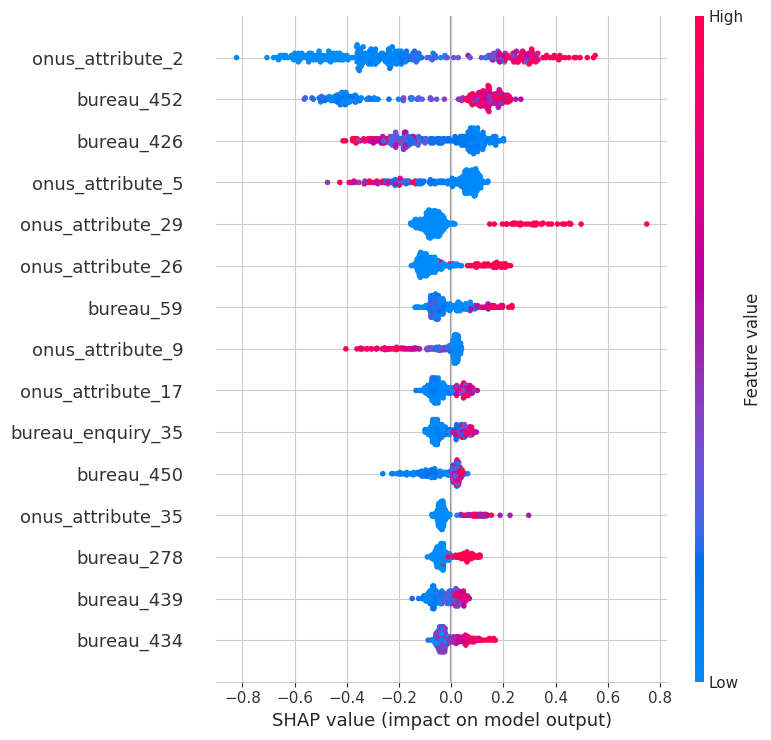

In [ ]:
explainer = shap.TreeExplainer(xgb)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test_imp), size=300, replace=False)
shap_values = explainer.shap_values(X_test_imp[sample_idx])

feature_names_final = all_feature_names  # saved in Section 5.2, before X was freed from memory

shap.summary_plot(shap_values, X_test_imp[sample_idx], feature_names=feature_names_final,
                   max_display=15, show=False)
plt.tight_layout()
plt.show()


### Figure 4 — XGBoost SHAP Summary

The SHAP summary plot shows the features with the largest overall contribution to XGBoost predictions across the sampled test observations.

Features positioned further toward positive SHAP values push predictions toward the `Bad` class, while negative values push predictions toward the `Good` class.

The plot is useful for understanding **model behaviour**, but it should not be interpreted as a causal analysis of default risk.

### Local SHAP Explanation — Highest-Risk Test Account

The notebook then selects the highest-risk-scored account and examines its individual SHAP contributions.

The actual supplied output identifies:

- XGBoost risk score: approximately **97.1/100**
- Actual `bad_flag`: **0**
- Strong contributing anonymised features include `onus_attribute_37`, `onus_attribute_2`, `onus_attribute_29`, `bureau_147` and `bureau_66`.

This is an intentionally honest example: the model can be strongly confident and still be wrong for an individual account.

In [ ]:
# Explain a single prediction — the highest-risk account in the test set, as an example
top_risk_idx = risk_table['XGBoost_RiskScore'].idxmax()
top_risk_pos = X_test.index.get_loc(top_risk_idx)
top_risk_account = risk_table.loc[top_risk_idx, 'account_number']

print(f"Account number with highest predicted risk: {top_risk_account}")
print(f"Test-set row index: {top_risk_idx}")
print(f"XGBoost risk score: {risk_table.loc[top_risk_idx, 'XGBoost_RiskScore']:.1f}/100")
print(f"Actual bad_flag: {risk_table.loc[top_risk_idx, 'bad_flag']}")
print()

single_shap = explainer.shap_values(X_test_imp[top_risk_pos:top_risk_pos+1])
contributions = pd.Series(single_shap[0], index=feature_names_final).sort_values(key=abs, ascending=False)
print("Top 10 contributing features for this specific account:")
contributions.head(10)


Account with highest predicted risk: index 51051, XGBoost risk score 97.0999984741211
Actual bad_flag: 0

Top 10 contributing features for this specific account:


,0
onus_attribute_37,0.447070
onus_attribute_2,0.358075
onus_attribute_29,0.261118
bureau_147,0.260123
bureau_66,0.202272
bureau_452,0.152079
onus_attribute_26,0.117197
bureau_59,0.114789
bureau_enquiry_1,0.103592
onus_attribute_31,0.098853


### Local explanation conclusion

The local SHAP analysis demonstrates the difference between **explainability and correctness**.

SHAP explains why the model produced a particular prediction. It does not guarantee that the prediction is correct.

The fact that the highest-risk account is a false positive makes this a useful portfolio example because it shows an understanding of model uncertainty and the practical consequences of class imbalance.

### 6.8 Optional Add-On — Unsupervised Risk Segmentation

K-Means clustering is included as an optional exploratory analysis.

Unlike the supervised classifiers, clustering does not use `bad_flag` to create the groups.

The clustering uses only the 16 group-level aggregate features rather than all 1,211 raw predictors. This reduces dimensionality and makes the resulting segments easier to describe at a high level.

### Methodological improvement

To make the segmentation evaluation more rigorous, the clusters should ideally be **fitted on the training set and then applied to the test set**.

If clustering is fitted on the entire dataset and the resulting bad rates are then reported, those bad rates are descriptive of the same data used to fit the clusters. That is acceptable for exploratory segmentation, but it should not be presented as out-of-sample evidence.

In [ ]:
cluster_features = engineered_cols  # 16 group-level aggregates

# Fit clustering transformations on the training partition only.
cluster_train = cluster_source.loc[train_indices, cluster_features]
cluster_test = cluster_source.loc[test_indices, cluster_features]

cluster_imputer = SimpleImputer(strategy='median')
X_cluster_train = pd.DataFrame(
    cluster_imputer.fit_transform(cluster_train),
    columns=cluster_features,
    index=cluster_train.index
)
X_cluster_test = pd.DataFrame(
    cluster_imputer.transform(cluster_test),
    columns=cluster_features,
    index=cluster_test.index
)

cluster_scaler = StandardScaler()
X_cluster_train_scaled = cluster_scaler.fit_transform(X_cluster_train)
X_cluster_test_scaled = cluster_scaler.transform(X_cluster_test)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
cluster_train_labels = kmeans.fit_predict(X_cluster_train_scaled)
cluster_test_labels = kmeans.predict(X_cluster_test_scaled)

cluster_source.loc[train_indices, 'Cluster'] = cluster_train_labels
cluster_source.loc[test_indices, 'Cluster'] = cluster_test_labels

# Report cluster sizes and bad rates on the held-out test partition.
cluster_summary = (
    cluster_source.loc[test_indices]
    .groupby('Cluster')
    .agg(
        Accounts=('account_number', 'count'),
        BadRate=('bad_flag', 'mean')
    )
    .round(4)
)

cluster_summary

,Accounts,BadRate
Cluster,,
0,10156,0.0050
1,19471,0.0297
2,67169,0.0111
3,10,0.0000


### Cluster interpretation

The original exploratory clustering output showed that one cluster had a materially higher bad rate than the overall dataset, while another very small cluster contained only 10 accounts.

That original result is useful diagnostically, but because the clusters were fitted using the full dataset, its bad-rate comparison should not be described as out-of-sample evidence.

The revised version fits K-Means on the training partition and assigns the held-out test accounts to those learned clusters. This makes the reported test bad rates more defensible as an evaluation of whether the unsupervised segmentation generalises.

## 7. Compare Model Performance

The models are evaluated on the same held-out test set.

### Why these metrics?

With only **1.42% bad accounts**, accuracy can be deceptive.

A model that predicted every account as Good would already achieve approximately 98.6% accuracy while identifying **zero** bad accounts.

The notebook therefore focuses on:

- **Precision:** Of accounts flagged Bad, how many were actually Bad?
- **Recall:** Of all actual Bad accounts, how many did the model identify?
- **F1:** Balance between precision and recall.
- **PR-AUC:** Quality of positive-class ranking under severe class imbalance.
- **ROC-AUC:** Overall ranking ability across classification thresholds.

PR-AUC is particularly important here because it directly focuses on the minority positive class.

In [ ]:
comparison_rows = []

for name, model in models.items():
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test_imp
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    report = classification_report(y_test, y_pred, output_dict=True)

    comparison_rows.append({
        'Model': name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Precision (Bad)': report['1']['precision'],
        'Recall (Bad)': report['1']['recall'],
        'F1 (Bad)': report['1']['f1-score'],
        'Accuracy': report['accuracy']
    })

    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['Good', 'Bad']))
    print(f'ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f}\n')

results_df = pd.DataFrame(comparison_rows).set_index('Model').round(3)
results_df


--- Logistic Regression ---
              precision    recall  f1-score   support

        Good       0.99      0.80      0.89     19088
         Bad       0.05      0.66      0.08       274

    accuracy                           0.80     19362
   macro avg       0.52      0.73      0.49     19362
weighted avg       0.98      0.80      0.88     19362

ROC-AUC: 0.771 | PR-AUC: 0.049

--- Random Forest ---
              precision    recall  f1-score   support

        Good       0.99      0.84      0.91     19088
         Bad       0.05      0.60      0.10       274

    accuracy                           0.84     19362
   macro avg       0.52      0.72      0.50     19362
weighted avg       0.98      0.84      0.90     19362

ROC-AUC: 0.818 | PR-AUC: 0.067

--- XGBoost ---
              precision    recall  f1-score   support

        Good       0.99      0.86      0.92     19088
         Bad       0.06      0.61      0.11       274

    accuracy                           0.85     1936

,ROC-AUC,PR-AUC,Precision (Bad),Recall (Bad),F1 (Bad),Accuracy
Model,,,,,,
Logistic Regression,0.771,0.049,0.045,0.657,0.085,0.799
Random Forest,0.818,0.067,0.052,0.602,0.095,0.838
XGBoost,0.836,0.083,0.058,0.613,0.106,0.854


### Model comparison — observed results

| Model | ROC-AUC | PR-AUC | Precision (Bad) | Recall (Bad) | F1 (Bad) | Accuracy |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.771 | 0.049 | 0.045 | 0.657 | 0.085 | 0.799 |
| Random Forest | 0.818 | 0.067 | 0.052 | 0.602 | 0.095 | 0.838 |
| **XGBoost** | **0.836** | **0.083** | **0.058** | **0.613** | **0.106** | **0.854** |

### Interpretation

**XGBoost is the strongest overall ranking model in this experiment.**

It achieves the highest ROC-AUC and PR-AUC and also has the highest precision and F1 among the three models at their default classification thresholds.

Logistic Regression achieves the highest recall, identifying about 65.7% of actual bad accounts, but does so with lower precision.

The trade-off is important: increasing recall means flagging more accounts, which can increase the number of false positives.

### Figure 5 — Confusion Matrices

The confusion matrices show the number of:

- True Negatives
- False Positives
- False Negatives
- True Positives

for each model at its default classification threshold.

Because the dataset is highly imbalanced, the absolute number of true negatives will be large. The more informative question is how many actual bad accounts are recovered and how many good accounts are incorrectly flagged.

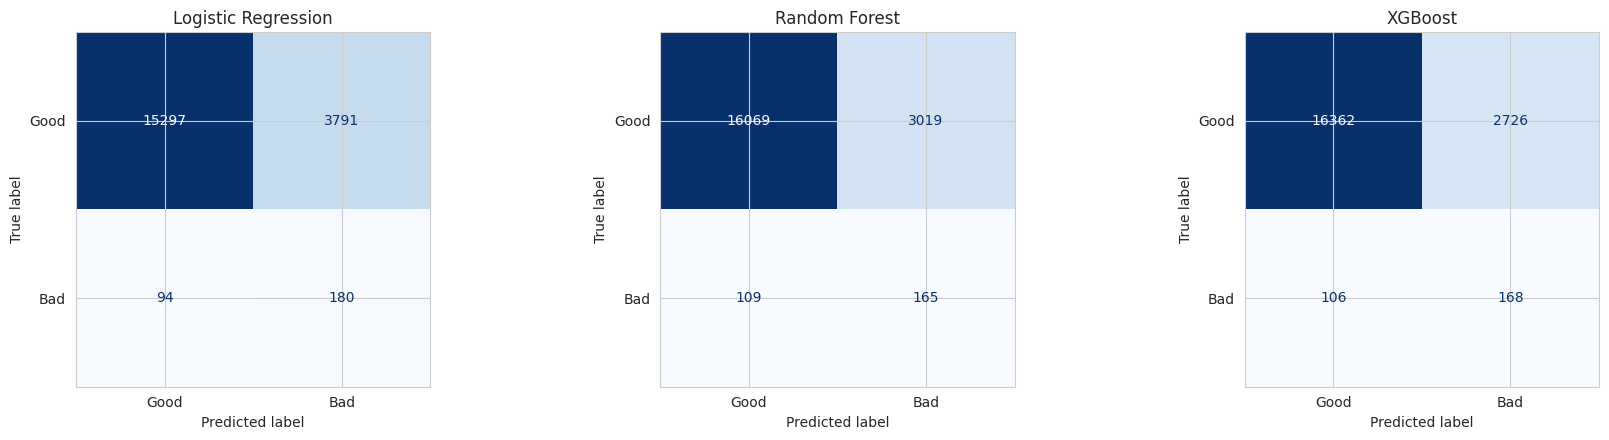

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test_imp
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Good', 'Bad']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()


### Figure 6 — ROC Curves

ROC curves show the relationship between:

- False Positive Rate
- True Positive Rate

across classification thresholds.

ROC-AUC is useful for measuring general ranking ability, but it can appear more favourable than the practical positive-class performance in a severely imbalanced dataset.

For that reason, this figure should be read together with the Precision-Recall analysis.

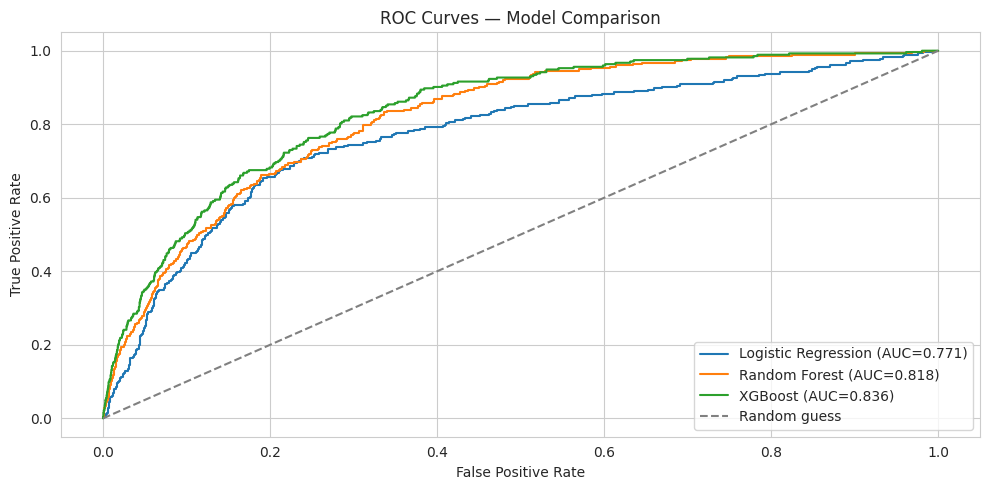

In [ ]:
fig, ax = plt.subplots()
for name, model in models.items():
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test_imp
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()


### Figure 7 — Precision-Recall Curves

Precision-Recall curves are particularly informative for this dataset because the Bad class occurs only 1.42% of the time.

The horizontal baseline represents the positive-class prevalence.

XGBoost's PR-AUC of approximately **0.083** is materially above the approximately **0.014** prevalence baseline, indicating useful ranking lift over random ordering.

However, PR-AUC should not be described as a direct percentage of correctly identified defaults, nor should the ratio between PR-AUC and prevalence be called a literal "lift" without specifying the evaluation definition.

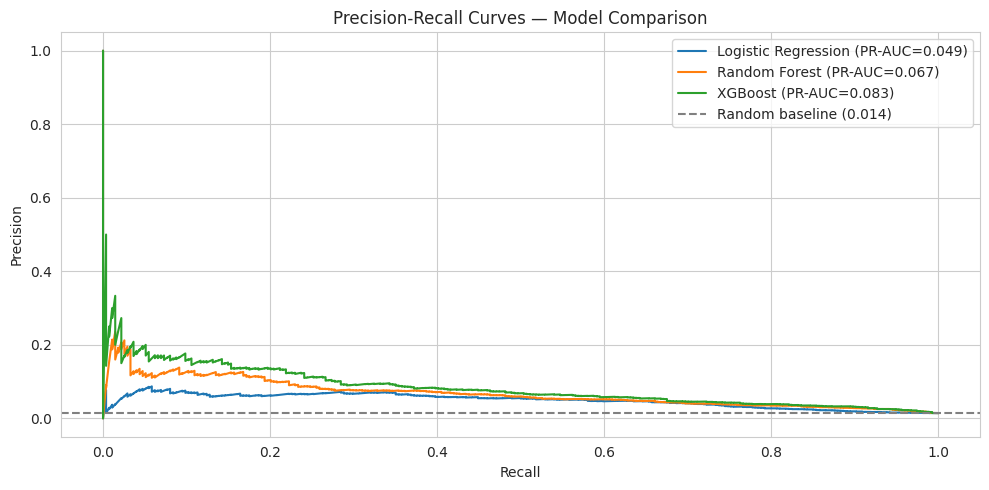

In [ ]:
# Precision-Recall curves — the more informative comparison at this class balance
fig, ax = plt.subplots()
for name, model in models.items():
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test_imp
    y_proba = model.predict_proba(X_te)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, label=f'{name} (PR-AUC={pr_auc:.3f})')

baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()


### Figure 8 — Precision, Recall and F1 Comparison

This summary compares the three most relevant threshold-based metrics for the Bad class.

The figure/table makes the trade-off visible:

- Logistic Regression prioritises recall.
- Random Forest provides an intermediate balance.
- XGBoost provides the strongest overall precision/F1 combination at the default threshold while retaining substantial recall.

In [ ]:
# Full precision/recall/f1/support breakdown, side by side
summary = pd.DataFrame({
    name: precision_recall_fscore_support(
        y_test,
        model.predict(X_test_scaled if name == 'Logistic Regression' else X_test_imp),
        average='binary'
    )[:3]
    for name, model in models.items()
}, index=['Precision', 'Recall', 'F1'])

summary


,Logistic Regression,Random Forest,XGBoost
Precision,0.045329,0.051822,0.058051
Recall,0.656934,0.602190,0.613139
F1,0.084806,0.095431,0.106061


## 8. Conclusion

### Key Findings

**1. XGBoost is the strongest overall model in this experiment.**

It achieves the best ROC-AUC (**0.836**) and PR-AUC (**0.083**) and also records the strongest precision (**0.058**) and F1 (**0.106**) for the Bad class at the default classification threshold.

**2. Recall and precision involve a clear business trade-off.**

Logistic Regression reaches the highest recall (**0.657**) but with lower precision (**0.045**). XGBoost reaches approximately **0.613 recall** with **0.058 precision**.

At this base rate, XGBoost's 5.8% precision means that only about 1 in 17 flagged accounts is actually bad at this particular threshold. That is not a failure of the ranking model; it demonstrates how difficult it is to obtain high positive predictive value when the underlying event rate is only 1.42%.

**3. PR-AUC provides more useful context than accuracy.**

XGBoost's PR-AUC of 0.083 is substantially above the approximately 0.014 positive-class prevalence baseline, showing meaningful ranking ability.

The correct interpretation is that the model can **prioritise accounts more effectively than random ordering**. It should not be described as a model that can reliably predict individual defaults.

**4. `onus_attribute` appears disproportionately informative.**

The strongest raw correlations are concentrated in the `onus_attribute` family, despite it being much smaller than the bureau and transaction families.

The SHAP analysis provides model-level evidence that several `onus_attribute` variables also contribute strongly to XGBoost predictions.

Because the feature names are anonymised, the business meaning of those variables cannot be established from this dataset alone.

**5. The highest-risk prediction is not guaranteed to be correct.**

The highest-scored test account receives an XGBoost risk score of approximately **97.1/100**, yet its actual `bad_flag` is **0**.

This is an important practical demonstration that model confidence and prediction correctness are different concepts.

### Limitations

- **Anonymised features:** The model can identify statistically important columns but cannot translate them into validated business reasons without a feature dictionary.
- **Severe class imbalance:** Only 1.42% of accounts are Bad, which makes high precision difficult and makes accuracy a poor primary metric.
- **Default classification thresholds:** The reported precision/recall/F1 values use the models' default decision thresholds rather than a threshold optimised for a real lending cost function.
- **Probability calibration:** Because imbalance weighting is used, raw predicted probabilities should not automatically be treated as calibrated probabilities of default.
- **Illustrative risk threshold:** `APPROVAL_THRESHOLD = 20` is not derived from business costs and must not be treated as a production approval rule.
- **Feature engineering assumptions:** The >50% missingness rule, median imputation and aggregate construction are modelling choices that should be validated through systematic model selection.
- **Clustering:** Unsupervised segmentation is exploratory. Even when fitted on training data, clusters should be assessed for stability and business usefulness before operational deployment.
- **No time dimension:** The supplied dataset is treated as a cross-sectional account-level classification problem. If historical application or repayment dates are available, temporal validation would be preferable to a purely random split.

### Recommended Next Steps

1. **Tune the classification threshold** using an explicit cost matrix for false positives and false negatives.
2. **Calibrate probabilities** using a validation set and methods such as isotonic regression or Platt scaling, then evaluate calibration with appropriate diagnostics.
3. Use **stratified cross-validation** or repeated validation for more stable model estimates.
4. Test additional imbalance strategies only after establishing strong validation methodology.
5. Perform **feature selection** using model-based importance and stability analysis.
6. Investigate whether the strongest `onus_attribute` features remain important across validation folds.
7. Validate the K-Means clusters for stability and business interpretability.
8. If temporal information becomes available, replace the random split with **time-based validation**.
9. Add fairness and subgroup performance analysis where legally and ethically appropriate.
10. Build a monitoring framework for model performance, calibration, drift and population stability.

### Regulatory & Governance Considerations

Credit risk is a high-impact modelling domain. A production system would require considerably more than a strong notebook metric.

Important areas include:

- Explainability
- Fair-lending considerations
- Documentation of model assumptions
- Validation and independent review
- Probability calibration
- Threshold governance
- Data and feature lineage
- Monitoring for population and performance drift
- Appropriate adverse-action reason generation

SHAP is useful for understanding model behaviour, but **SHAP alone is not a complete regulatory explanation system**. A production workflow would need validated feature definitions and a controlled process for translating model factors into appropriate, accurate and reviewable decision reasons.

### Portfolio Takeaway

This project demonstrates more than training a classifier.

It demonstrates the ability to:

- Work with a high-dimensional financial dataset
- Build a memory-efficient data-loading strategy
- Diagnose extreme class imbalance
- Prevent preprocessing leakage
- Engineer aggregate features from anonymised feature families
- Compare linear and non-linear classifiers
- Evaluate models using imbalance-aware metrics
- Analyse precision/recall trade-offs
- Explain individual predictions using SHAP
- Explore unsupervised customer segmentation
- Identify limitations instead of overstating model performance
- Translate machine-learning results into credit-risk and governance considerations

The central lesson is that **a useful credit-risk model is not defined by AUC alone**. Model performance, calibration, threshold selection, explainability, fairness, validation and business cost all need to be considered before a predictive model could responsibly support lending decisions.